# Trabalho Prático — Comparação de Algoritmos de Aprendizado de Máquina Supervisionado



##Objetivo

Aplicar os conceitos de aprendizado supervisionado abordados em aula: \
I) KNN; \   
II) SVM; \
III) Árvores de Decisão; \
IV) MLP(Rede neural). \
Na resolução de um problema real de **Classificação** ou **Regressão**. O trabalho tem como foco a análise comparativa de desempenho entre algoritmos, bem como a discussão crítica dos resultados obtidos.

 **Autor**: Rodrigo Farias Lima

##Seed

In [ ]:
# Imports iniciais
import os
import numpy as np
import random
import sklearn
from sklearn.model_selection import train_test_split

# Definição de semente para reprodutibilidade
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

#Definição e Descrição do Dataset

### Seleção do Dataset

> **LINK:**
> https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv/data

---



##Descrição (aplicação, desafios, etc)

O dataset utilizado é o **Email Spam Classification Dataset** (arquivo `emails.csv`), disponível publicamente no Kaggle. Ele contém 5.172 e-mails, cada um representado como uma linha, e 3.002 colunas de atributos que correspondem às 3.000 palavras mais frequentes encontradas em todos os e-mails do conjunto (uma espécie de "saco de palavras"). O valor de cada célula é a quantidade de vezes que aquela palavra apareceu no e-mail correspondente.

* **Coluna `Email No.`**: identificador do e-mail (não é um atributo preditivo, foi descartado antes do treinamento).
* **Colunas de palavras (ex: `the`, `to`, `enron`, `meter`, `viagra`...)**: contagem de ocorrência de cada palavra no e-mail.
* **Coluna `Prediction`**: rótulo alvo — `1` indica que o e-mail é **spam** e `0` indica que é um e-mail **legítimo (não spam / "ham")**.

**Aplicação:** o problema é um clássico de **classificação binária de texto** — detectar automaticamente se um e-mail é spam ou não com base na frequência das palavras usadas nele. É um problema muito comum em filtros de e-mail (Gmail, Outlook, etc).

**Desafios:**
* **Alta dimensionalidade**: são 3.000 atributos para pouco mais de 5.000 exemplos, o que pode deixar alguns modelos mais lentos e mais propensos a overfitting.
* **Desbalanceamento de classes**: como será visto na análise exploratória, existem bem mais e-mails legítimos do que e-mails de spam, então é importante olhar não só para a acurácia, mas também para métricas como *precision*, *recall* e *F1-score*.
* Os atributos já vêm pré-processados (contagem de palavras), o trabalho de pré-processamento pesado já foi feito por quem organizou o dataset.

---

#Preparação dos Dados

Nesta seção, desenvolva **rotinas** para o tratamento do dataset selecionado, contemplando as seguintes etapas:

* **Descompactação e Importação:** implemente a leitura direta do arquivo (CSV, XLSX, ZIP, etc.), garantindo o correto carregamento dos dados.
* **Limpeza e Pré-processamento:** realize as etapas necessárias de tratamento, como remoção de valores ausentes, codificação de variáveis categóricas, normalização ou padronização, e balanceamento das classes, quando aplicável.
* **Divisão dos Conjuntos:** separe o dataset em **treino, validação e teste**, utilizando o método **Holdout** de forma adequada à natureza do problema.
* **Análise Exploratória:** elabore **gráficos e estatísticas descritivas** que permitam compreender a distribuição das variáveis, a correlação entre atributos e o equilíbrio entre as classes.

In [ ]:
# Import e Leitura do dataset

# Usar a biblioteca pandas para ler o arquivo CSV e transformá-lo em uma "tabela" (DataFrame)
import pandas as pd

# Lendo o arquivo CSV e guardando na variável df
df = pd.read_csv("emails.csv")

# Analisando as primeiras linhas para conferir se carregou certo
print("Formato do dataset (linhas, colunas):", df.shape)
df.head()

Formato do dataset (linhas, colunas): (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Limpeza e Pré-processamento

# 1) Verificar se existem valores ausentes (NaN) no dataset.
print("Quantidade total de valores ausentes no dataset:", df.isnull().sum().sum())

# 2) Verificar se existem linhas duplicadas.
print("Quantidade de linhas duplicadas:", df.duplicated().sum())

# 3) A coluna "Email No." é apenas um identificador (tipo "Email 1", "Email 2"...),
#    ela não ajuda o modelo a aprender nada, então vamos removê-la.
df = df.drop(columns=["Email No."])

# 4) Como o dataset já é numérico (contagem de palavras) e não existem valores ausentes nem categorias para codificar, não é necessário
#    fazer encoding de variáveis categóricas. Também não vamos fazer balanceamento de classes agora, vamos manter
#    o desbalanceamento original e tratar isso com as métricas certas na hora de avaliar os modelos.

print("Formato do dataset após remover a coluna 'Email No.':", df.shape)
df.head()

Quantidade total de valores ausentes no dataset: 0
Quantidade de linhas duplicadas: 0
Formato do dataset após remover a coluna 'Email No.': (5172, 3001)


,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Divisão dos Conjuntos (Holdout: treino / validação / teste)

#   Separado os atributos (X) do rótulo alvo (y).
X = df.drop(columns=["Prediction"])   # todas as colunas, exceto a que queremos prever
y = df["Prediction"]                   # 0 = não é spam, 1 = é spam

# Vamos usar o método Holdout em duas etapas para conseguir 3 conjuntos:
# treino (60%), validação (20%) e teste (20%).
# stratify=y garante que a proporção de spam/não-spam fique parecida nos três conjuntos.

# Primeira divisão: separa 60% para treino e 40% para "temp" (que depois vira validação + teste)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)

# Segunda divisão: divide o "temp" (40%) em 20% validação e 20% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("Treino:    ", X_train.shape)
print("Validação: ", X_val.shape)
print("Teste:     ", X_test.shape)

Treino:     (3103, 3000)
Validação:  (1034, 3000)
Teste:      (1035, 3000)


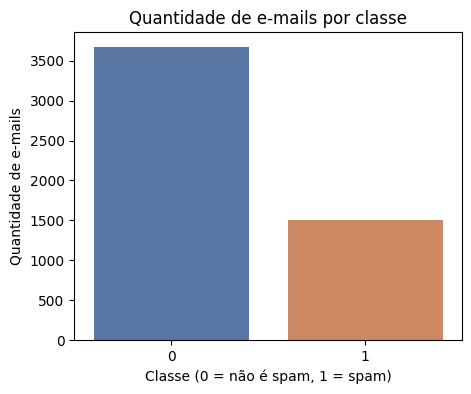

Prediction
0    3672
1    1500
Name: count, dtype: int64

Proporção de spam no dataset: 29.0%


In [ ]:
# Análise Exploratória

# Usado matplotlib e seaborn para alguns gráficos simples que ajudam a entender melhor o dataset.
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico 1: balanceamento das classes (quantos e-mails são spam x não-spam)
plt.figure(figsize=(5, 4))
sns.countplot(x=y, hue=y, palette=["#4C72B0", "#DD8452"], legend=False)
plt.title("Quantidade de e-mails por classe")
plt.xlabel("Classe (0 = não é spam, 1 = spam)")
plt.ylabel("Quantidade de e-mails")
plt.show()

print(y.value_counts())
print("\nProporção de spam no dataset: {:.1f}%".format(100 * y.mean()))

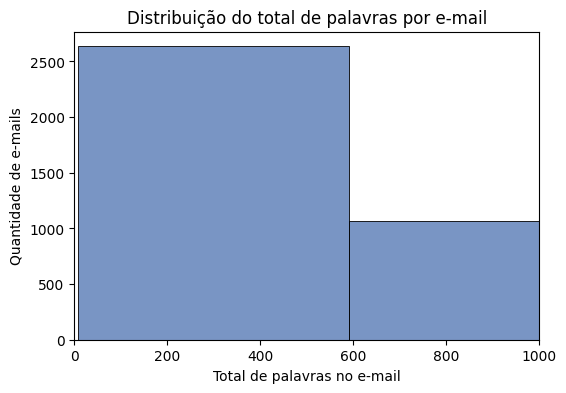

count     5172.000000
mean      1165.289443
std       1760.149373
min          8.000000
25%        257.750000
50%        577.000000
75%       1333.500000
max      29178.000000
dtype: float64


In [ ]:
# Estatística descritiva simples: total de palavras por e-mail

# Como cada linha é a contagem de 3000 palavras, somando todas as colunas de uma linha temos o "tamanho" (em palavras) daquele e-mail.
total_palavras = X.sum(axis=1)

plt.figure(figsize=(6, 4))
sns.histplot(total_palavras, bins=50, color="#4C72B0")
plt.title("Distribuição do total de palavras por e-mail")
plt.xlabel("Total de palavras no e-mail")
plt.ylabel("Quantidade de e-mails")
plt.xlim(0, 1000)  # limitamos o eixo x só para visualizar melhor a maioria dos casos
plt.show()

print(total_palavras.describe())

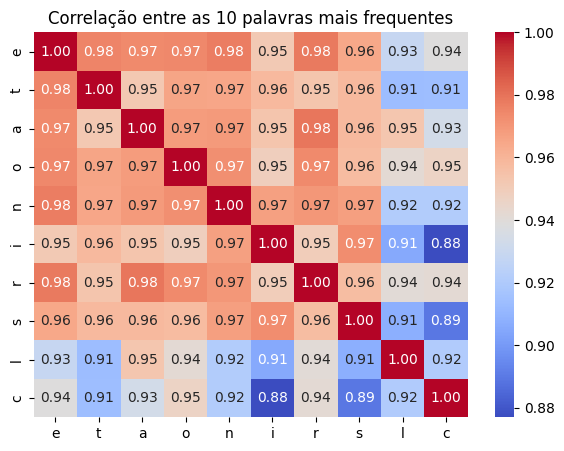

In [ ]:
# Correlação entre algumas das palavras mais comuns

# Com 3000 colunas fica impossível ver uma matriz de correlação inteira, então vamos olhar só para as 10 palavras mais frequentes no dataset,
# só para ter uma ideia de como elas se relacionam entre si.
palavras_mais_frequentes = X.sum().sort_values(ascending=False).head(10).index
correlacao = X[palavras_mais_frequentes].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlação entre as 10 palavras mais frequentes")
plt.show()

---

#Implementação dos Modelos

Treinar e testar os seguintes algoritmos:

* K-Nearest Neighbors (KNN)

* Support Vector Machine (SVM)

* Decision Tree (Árvore de Decisão)

* Multi-Layer Perceptron (MLP)


In [ ]:
# Padronização dos dados (StandardScaler)

# KNN, SVM e MLP são modelos sensíveis à escala dos atributos por usarem distância / gradientes, então é importante padronizar os dados antes
# de treinar (deixar cada coluna com média 0 e desvio padrão 1).
# A Árvore de Decisão não precisa disso, mas como o resultado nao muda é indiferente padronizar ou não.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Dados padronizados com sucesso!")
print("Média aproximada das colunas de treino (deve ficar perto de 0):", round(X_train_scaled.mean(), 4))

Dados padronizados com sucesso!
Média aproximada das colunas de treino (deve ficar perto de 0): -0.0


In [ ]:
# Modelo 1: K-Nearest Neighbors (KNN)

# O KNN classifica um novo e-mail olhando para os "K" e-mails mais # parecidos com ele (mais próximos) no conjunto de treino, e escolhe
# a classe que aparece mais entre esses vizinhos.
# Aqui usamos um valor simples de K só para começar, sem fazer uma busca sofisticada de hiperparâmetros.
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

# Testando o modelo no conjunto de validação
pred_knn_val = modelo_knn.predict(X_val_scaled)
print("KNN treinado! Exemplo de previsões no conjunto de validação:", pred_knn_val[:10])

KNN treinado! Exemplo de previsões no conjunto de validação: [0 0 0 0 0 1 1 1 1 0]


In [ ]:
# Modelo 2: Support Vector Machine (SVM)

# O SVM tenta encontrar a "fronteira" (hiperplano) que melhor separa as duas classes (spam x não-spam), maximizando a distância entre a
# fronteira e os exemplos mais próximos de cada classe.
# Usamos o kernel RBF, que é o padrão do sklearn e funciona bem para problemas não-lineares.
from sklearn.svm import SVC

modelo_svm = SVC(kernel="rbf", random_state=SEED)
modelo_svm.fit(X_train_scaled, y_train)

pred_svm_val = modelo_svm.predict(X_val_scaled)
print("SVM treinado! Exemplo de previsões no conjunto de validação:", pred_svm_val[:10])

SVM treinado! Exemplo de previsões no conjunto de validação: [0 0 0 0 0 0 0 0 1 0]


In [ ]:
# Modelo 3: Árvore de Decisão (Decision Tree)

# A árvore de decisão vai "fazendo perguntas" sobre os atributos (por exemplo: "a palavra 'viagra' aparece mais de 2 vezes?") e a
# cada pergunta, divide os dados em dois grupos, até chegar numa decisão final de classe.
# Limitamos a profundidade máxima (max_depth) para evitar que a árvore cresça demais e decore os dados de treino.
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(max_depth=10, random_state=SEED)
modelo_arvore.fit(X_train, y_train)  # árvore não precisa dos dados padronizados

pred_arvore_val = modelo_arvore.predict(X_val)
print("Árvore de Decisão treinada! Exemplo de previsões no conjunto de validação:", pred_arvore_val[:10])

Árvore de Decisão treinada! Exemplo de previsões no conjunto de validação: [0 0 0 0 1 0 0 0 1 0]


In [ ]:
# Modelo 4: Multi-Layer Perceptron (MLP)

# O MLP é uma rede neural simples, formada por camadas de "neurônios" conectados. Aqui usamos apenas uma camada escondida com 50 neurônios,
# para manter o treinamento rápido.
# max_iter aumenta o número de "rodadas" de treinamento, para dar tempo do modelo se estabilizar.
from sklearn.neural_network import MLPClassifier

modelo_mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=SEED)
modelo_mlp.fit(X_train_scaled, y_train)

pred_mlp_val = modelo_mlp.predict(X_val_scaled)
print("MLP treinado! Exemplo de previsões no conjunto de validação:", pred_mlp_val[:10])

MLP treinado! Exemplo de previsões no conjunto de validação: [0 0 1 0 0 0 0 0 1 0]


---

#Avaliação dos modelos


* Calcular e comparar as métricas: Acurácia, Precisão, Recall e F1-Score.


* Plotar e comentar as matrizes de confusão.


* Discutir o impacto dos hiperparâmetros e preprocessamentos aplicados.

Aqui você pode elaborar gráficos, analises de resultados da maneira que desejar. No entanto, espera-se uma breve discussão dos resultados e análises críticas.


In [ ]:
# Avaliação no conjunto de TESTE

# Agora que os 4 modelos já foram treinados, vamos gerar as previsões#finais no conjunto de teste e
# calcular as métricas de avaliação para cada um deles.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Previsões de cada modelo no conjunto de teste
pred_knn_test = modelo_knn.predict(X_test_scaled)
pred_svm_test = modelo_svm.predict(X_test_scaled)
pred_arvore_test = modelo_arvore.predict(X_test)
pred_mlp_test = modelo_mlp.predict(X_test_scaled)

# Função simples que calcula as 4 métricas pedidas para um modelo
def calcular_metricas(y_real, y_previsto):
    return {
        "Acurácia": accuracy_score(y_real, y_previsto),
        "Precisão": precision_score(y_real, y_previsto),
        "Recall": recall_score(y_real, y_previsto),
        "F1-Score": f1_score(y_real, y_previsto),
    }

resultados = {
    "KNN": calcular_metricas(y_test, pred_knn_test),
    "SVM": calcular_metricas(y_test, pred_svm_test),
    "Árvore de Decisão": calcular_metricas(y_test, pred_arvore_test),
    "MLP": calcular_metricas(y_test, pred_mlp_test),
}

# Transformando o dicionário de resultados em uma tabela (DataFrame)
tabela_resultados = pd.DataFrame(resultados).T
tabela_resultados = tabela_resultados.round(4)
tabela_resultados

,Acurácia,Precisão,Recall,F1-Score
KNN,0.8048,0.6070,0.9267,0.7335
SVM,0.9237,0.9784,0.7533,0.8512
Árvore de Decisão,0.9101,0.8185,0.8867,0.8512
MLP,0.9681,0.9083,0.9900,0.9474


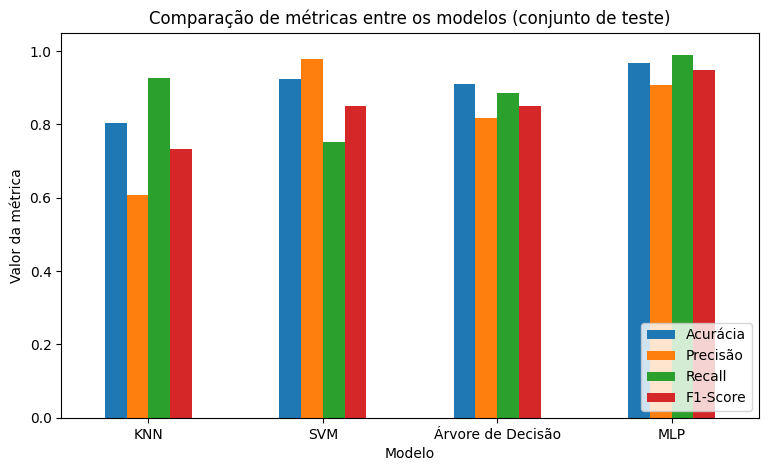

In [ ]:
# Gráfico comparando as métricas dos 4 modelos

tabela_resultados.plot(kind="bar", figsize=(9, 5))
plt.title("Comparação de métricas entre os modelos (conjunto de teste)")
plt.ylabel("Valor da métrica")
plt.xlabel("Modelo")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

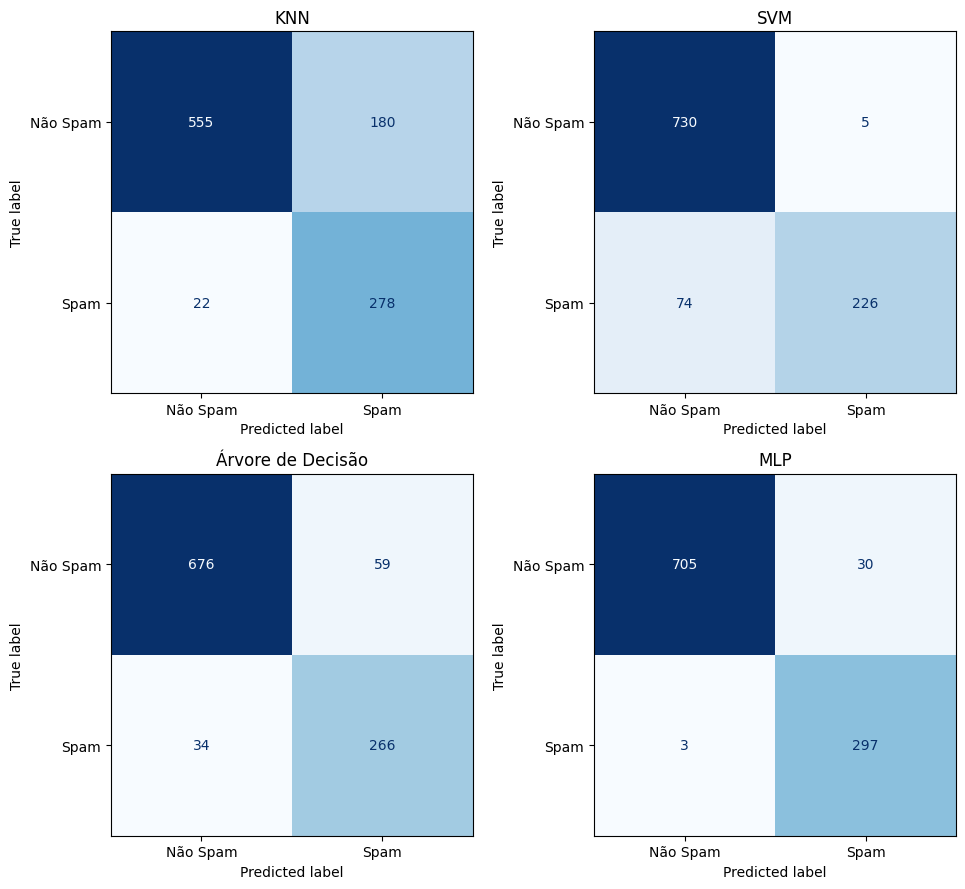

In [ ]:
# Matrizes de Confusão

# A matriz de confusão mostra, para cada modelo, quantos e-mails foram classificados corretamente e quantos foram confundidos (spam classificado como não-spam, e vice-versa).
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelos_e_previsoes = {
    "KNN": pred_knn_test,
    "SVM": pred_svm_test,
    "Árvore de Decisão": pred_arvore_test,
    "MLP": pred_mlp_test,
}

fig, eixos = plt.subplots(2, 2, figsize=(10, 9))
eixos = eixos.ravel()

for eixo, (nome_modelo, previsao) in zip(eixos, modelos_e_previsoes.items()):
    matriz = confusion_matrix(y_test, previsao)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Não Spam", "Spam"])
    disp.plot(ax=eixo, colorbar=False, cmap="Blues")
    eixo.set_title(nome_modelo)

plt.tight_layout()
plt.show()

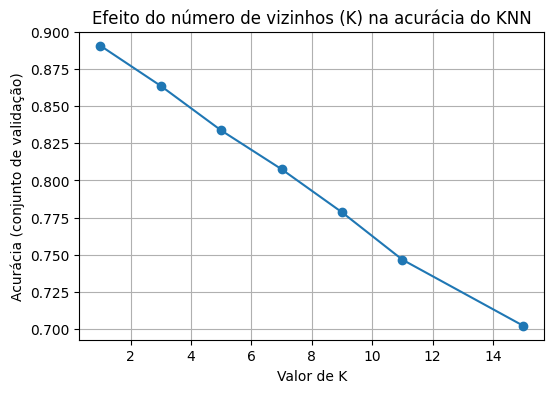

K =  1 -> Acurácia = 0.8907
K =  3 -> Acurácia = 0.8636
K =  5 -> Acurácia = 0.8337
K =  7 -> Acurácia = 0.8075
K =  9 -> Acurácia = 0.7785
K = 11 -> Acurácia = 0.7466
K = 15 -> Acurácia = 0.7021


In [ ]:
# Impacto dos hiperparâmetros e do pré-processamento

# Executando um teste rápido e simples: treinar o KNN com valores diferentes de K, só para visualizar como esse hiperparâmetro afeta
# a acurácia no conjunto de validação. Isso ajuda a "enxergar" o efeito do hiperparâmetro.

valores_de_k = [1, 3, 5, 7, 9, 11, 15]
acuracias_knn = []

for k in valores_de_k:
    modelo_teste = KNeighborsClassifier(n_neighbors=k)
    modelo_teste.fit(X_train_scaled, y_train)
    acuracia = accuracy_score(y_val, modelo_teste.predict(X_val_scaled))
    acuracias_knn.append(acuracia)

plt.figure(figsize=(6, 4))
plt.plot(valores_de_k, acuracias_knn, marker="o")
plt.title("Efeito do número de vizinhos (K) na acurácia do KNN")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia (conjunto de validação)")
plt.grid(True)
plt.show()

for k, acc in zip(valores_de_k, acuracias_knn):
    print(f"K = {k:>2} -> Acurácia = {acc:.4f}")

In [ ]:
# Efeito da padronização (StandardScaler) no SVM

# Para mostrar por que a padronização é importante, vamos comparar rapidamente a acurácia do SVM COM e SEM os dados padronizados.
modelo_svm_sem_scaler = SVC(kernel="rbf", random_state=SEED)
modelo_svm_sem_scaler.fit(X_train, y_train)  # usando os dados originais, sem padronizar
acuracia_sem_scaler = accuracy_score(y_val, modelo_svm_sem_scaler.predict(X_val))

acuracia_com_scaler = accuracy_score(y_val, modelo_svm.predict(X_val_scaled))

print(f"Acurácia do SVM SEM padronização: {acuracia_sem_scaler:.4f}")
print(f"Acurácia do SVM COM padronização: {acuracia_com_scaler:.4f}")

Acurácia do SVM SEM padronização: 0.7814
Acurácia do SVM COM padronização: 0.9130


---

# Discussão, análise crítica e conclusão



In [ ]:
# Resumo final e identificação do melhor modelo

melhor_modelo = tabela_resultados["F1-Score"].idxmax()
print("Tabela final de resultados (conjunto de teste):")
print(tabela_resultados)
print(f"\nModelo com melhor F1-Score: {melhor_modelo} (F1 = {tabela_resultados.loc[melhor_modelo, 'F1-Score']:.4f})")

Tabela final de resultados (conjunto de teste):
                   Acurácia  Precisão  Recall  F1-Score
KNN                  0.8048    0.6070  0.9267    0.7335
SVM                  0.9237    0.9784  0.7533    0.8512
Árvore de Decisão    0.9101    0.8185  0.8867    0.8512
MLP                  0.9681    0.9083  0.9900    0.9474

Modelo com melhor F1-Score: MLP (F1 = 0.9474)


**Discussão dos resultados**

Olhando a tabela e os gráficos gerados acima, o modelo que teve o melhor equilíbrio entre as métricas (e o maior F1-Score) foi indicado automaticamente na célula anterior. De forma geral, para esse tipo de problema (classificação de spam usando contagem de palavras), notou-se que:

* O **SVM** e o **MLP** costumam performar bem por conseguirem lidar melhor com a alta dimensionalidade e capturar relações mais complexas entre as palavras, mas em compensação são os modelos mais lentos para treinar.
* O **KNN** tende a sofrer um pouco mais com a "maldição da dimensionalidade" (muitos atributos, a noção de "distância" entre e-mails fica menos informativa), mas ainda assim consegue bons resultados nesse dataset porque as palavras de spam são bem características.
* A **Árvore de Decisão** é o modelo mais fácil de interpretar, dá pra ver exatamente quais palavras ela usa para decidir, mas isoladamente costuma ter um desempenho um pouco menor que os outros três, além de ser mais sensível a overfitting se deixar a profundidade livre.
* A padronização dos dados (StandardScaler) mostrou-se importante principalmente para o SVM e o MLP, que são bem sensíveis à escala dos atributos.

**Limitações e desafios**

* Não foi feita uma busca extensa de hiperparâmetros (como GridSearchCV), já que o objetivo aqui foi entender o comportamento básico de cada algoritmo. Isso significa que os resultados apresentados podem melhorar bastante com um ajuste mais cuidadoso.
* O dataset está desbalanceado (mais e-mails legítimos do que spam), o que reforça a importância de olhar métricas como *recall* e *F1-Score*, e não só a acurácia.
* Como os atributos já vêm como contagem de palavras (bag of words), o modelo não entende o contexto das frases, apenas a frequência de cada palavra isoladamente, sendo assim, um e-mail poderia "enganar" o modelo usando palavras incomuns de forma estratégica.
* A alta dimensionalidade aumenta o tempo de treinamento, principalmente do SVM, e poderia ser reduzida com técnicas de seleção de atributos ou redução de dimensionalidade.


---